# Chapter 52: Time Series Feature Engineering

**How much does a backtest flatter a model whose lag features read days that would not yet exist at the forecast origin?**

A perfectly aligned array can still contain values that are unavailable when the forecast is made. A lag-1 column is safe for a next-day forecast and a leak for a three-day one, and the backtest cannot tell the difference because it holds the true values.

*Constructed data with strong short-range autocorrelation; the sizes of these gaps are properties of this generator, not a competition result. The production-style score is only modestly worse than the direct model, so the main damage of a leaky builder is the false backtest, not the final forecast.*

## The experiment

Ten constructed panels of 30 daily series, each with a weekday profile and autocorrelated noise. A gradient boosting regressor forecasts the value h days after the origin, where h is the control, and is scored by mean absolute error (MAE) on the 150 days after the training period. Two pipelines are built: a shift-based builder that creates lags 1, 2, 3, 7, 14 and 21 and a 7-day mean ending yesterday, and a direct builder that keeps only lags of at least h days and a 7-day mean ending at the origin. The shift-based model is scored twice: in a backtest with the true lag values, and as production would run it, with each lag that is still in the future filled by the latest value known at the origin. An origin test then perturbs every value after the origin and counts the feature columns that move.

In [1]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor

from kaggle_companion.activities._common import clean

SEED = 52
REPLICATES = 10             # independent panels of constructed series; every estimate is their mean
N_SERIES, DAYS, TRAIN_END = 30, 450, 300
LAGS = [1, 2, 3, 7, 14, 21]  # the lag set a shift-based builder would create


def generate(rng):
    """Daily series with a weekday profile and autocorrelated noise (AR coefficient 0.8), one row per series."""
    series = []
    for _ in range(N_SERIES):
        level = rng.uniform(50, 150)
        profile = rng.normal(0, 1, 7)
        profile = (profile - profile.mean()) * level * 0.06
        noise = np.zeros(DAYS)
        for t in range(1, DAYS):
            noise[t] = 0.8 * noise[t - 1] + rng.normal(0, level * 0.04)
        series.append(level + profile[np.arange(DAYS) % 7] + noise)
    return np.array(series)


def features(y, target_days, horizon, kind):
    """Feature columns for the target days. The forecast origin is `horizon` days earlier.

    leaky:  lag k reads day t-k, which is what shift(k) does; at horizon > k that day is still in the future.
    stale:  the same columns as production would fill them, with the latest value known at the origin.
    honest: built at the origin: keep only lags k >= horizon, and a 7-day mean ending at the origin.
    """
    origin = target_days - horizon
    cols = []
    for k in LAGS:
        if kind == "honest" and k < horizon:
            continue
        source = np.minimum(target_days - k, origin) if kind == "stale" else target_days - k
        cols.append(y[:, source])
    end = target_days - 1 if kind == "leaky" else origin   # the rolling mean ends yesterday, or at the origin
    total = np.concatenate([np.zeros((len(y), 1)), np.cumsum(y, axis=1)], axis=1)
    cols.append((total[:, end + 1] - total[:, end - 6]) / 7)
    cols.append(np.tile(target_days % 7, (len(y), 1)))     # weekday is known in advance
    return np.column_stack([c.reshape(-1) for c in cols])


def new_model():
    return HistGradientBoostingRegressor(max_iter=80, learning_rate=0.1, max_leaf_nodes=12, random_state=0)


def one_panel(horizon, replicate):
    rng = np.random.default_rng(SEED * 1000 + replicate)
    y = generate(rng)
    train = np.arange(30, TRAIN_END)
    test = np.arange(TRAIN_END + horizon, DAYS)             # every test origin is after the last training day
    y_train, y_test = y[:, train].reshape(-1), y[:, test].reshape(-1)
    leaky = new_model().fit(features(y, train, horizon, "leaky"), y_train)
    honest = new_model().fit(features(y, train, horizon, "honest"), y_train)
    mae = lambda pred: float(np.mean(np.abs(pred - y_test)))
    out = {"backtest": mae(leaky.predict(features(y, test, horizon, "leaky"))),
           "deployed": mae(leaky.predict(features(y, test, horizon, "stale"))),
           "honest": mae(honest.predict(features(y, test, horizon, "honest"))),
           "seasonal_naive": mae(y[:, test - 7].reshape(-1))}  # same weekday last week, usable at every horizon here
    # Origin test from the chapter: change every value published after the origin and see which features move.
    target = np.array([test[0]])
    shifted = y.copy()
    shifted[:, target[0] - horizon + 1:] += rng.normal(0, 10, shifted[:, target[0] - horizon + 1:].shape)
    for kind in ("leaky", "honest"):
        before, after = features(y, target, horizon, kind), features(shifted, target, horizon, kind)
        out["moved_" + kind] = int((np.abs(before - after) > 1e-9).any(axis=0).sum())
        out["columns_" + kind] = before.shape[1]
    return out


def run(horizon):
    panels = [one_panel(horizon, i) for i in range(REPLICATES)]
    mean = lambda key: float(np.mean([p[key] for p in panels]))
    keys = ["backtest", "deployed", "honest", "seasonal_naive"]
    return clean({
        "horizon": horizon,
        **{k: mean(k) for k in keys},
        "per_panel": {k: [p[k] for p in panels] for k in keys},
        "moved_leaky": panels[0]["moved_leaky"], "columns_leaky": panels[0]["columns_leaky"],
        "moved_honest": panels[0]["moved_honest"], "columns_honest": panels[0]["columns_honest"],
        "replicates": REPLICATES, "series": N_SERIES, "test_days": DAYS - TRAIN_END - horizon,
    })


## Measure it across the control

The control is **forecast horizon (days between the origin and the target day)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch52 import explain

VALUES = [1, 3, 5, 7]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                         1       3       5       7
Shift-based backtest MAE              4.96    4.96    4.97    4.96
Shift-based, run at the origin        4.96    5.95    6.49    6.28
Direct model MAE                      4.96    5.69    6.03    6.03
Hidden error (direct - backtest)      0.00    0.73    1.06    1.07
Columns that move after the origin  0 of 8  3 of 8  4 of 8  4 of 8


## Look at it

The figure shows the default setting, forecast horizon (days between the origin and the target day) = 3.

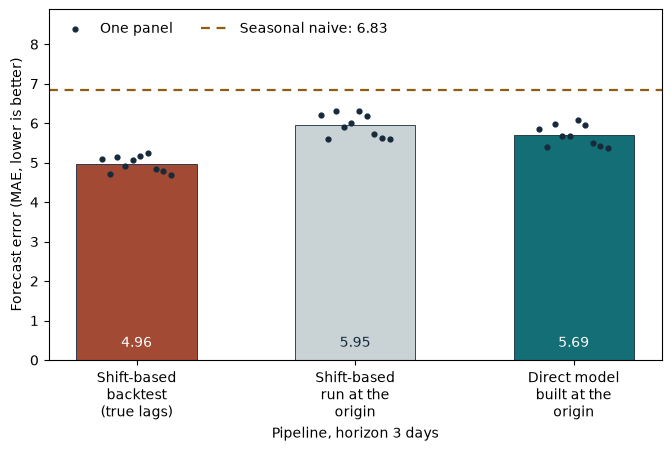

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch52 import draw, NCOLS, HEIGHT

DEFAULT = 3
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

At a horizon of 3 days the shift-based backtest reports an MAE of 4.96. The direct model, which uses only history available at the origin, scores 5.69, so 5.69 - 4.96 = 0.73 is the error the backtest hides. Run at the origin, the shift-based model scores 5.95. The origin test moves 3 of 8 shift-based columns and 0 of 6 direct columns. The seasonal-naive forecast scores 6.83.

- Hidden error: 5.69 - 4.96 = 0.73 (direct model minus shift-based backtest).
- Production penalty of the shift-based model: 5.95 - 5.69 = +0.26 (run at the origin minus direct).
- Share of the shift-based columns that read after the origin: 3 of 8.
- Direct model against seasonal naive: 5.69 - 6.83 = -1.14.

## Apply this to your competition

- Write down the forecast origin and the reporting delay of each input before writing any shift, and store forecast_origin with every training row.
- Build features from history at or before the origin: keep lags of at least the horizon, and shift before rolling or differencing.
- Run the origin test on the feature builder: change values published after the origin and assert that the inputs stay unchanged.
- If a shift-based backtest looks far better than a seasonal-naive baseline that works at the real horizon, suspect the lags before celebrating the model.

Book location: Chapter 52, One-Step and Three-Step Forecasts Use Different Histories.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)